In [ ]:
# Data loading and synchronization 
from ingestion.data_paths import DataStorageManager
from ingestion.ephys_sync import DataSyncManager
from ingestion.kilosort_data_import import KilosortData
from video.behavioral_events import BehavioralEventsData

animal_id = "rat631"
session_date = "20251216"
data_storage = DataStorageManager(animal_id, session_date, auto_load=True)
behavior_data = BehavioralEventsData(data_storage)
ks_data = KilosortData(data_storage)
sync = DataSyncManager(data_storage, dio_channel=1)
behavior_data.synchronize_with_ephys(sync, create_new_columns=True)

Loading data paths for rat631/20251216
Data Availability Summary:
  - Ephys (Kilosort): ✓
  - DIO channels: [1, 2, 3, 4]
  - Video files: 48
  - Tracking files: 1
  - Behavioral event files: 1
  - Pulse log: ✓
Successfully loaded 1 file(s) with 641 total events
✓ Available behavior types: {'EC': 376, 'F': 71, 'PS': 71, 'C': 46, 'SN': 31, 'D': 16, 'P': 15, 'PO': 5, 'R': 5, 'HD': 4, 'UD': 1}
Cluster info file not found. Using KS labels.
The session is not curated! Using KS labels.
Loading sync data for rat631/20251216


c:\Users\proskurinm\GitHub\habitat_pipeline\ingestion\trodes_to_python.py:63: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return np.dtype(typearr)


Found start sequence match: B[74791] -> E[0]
=== Sync Mapping Summary ===
Method: Linear regression
R²: 1.000000
Matches: 158
Slope: 1.00000721


True


=== Firing Pattern Quality Metrics Summary ===
Total clusters: 734
Passed quality checks: 307 (41.8%)
Failed quality checks: 427

Overall Statistics:
  Firing Rate: 2.14 ± 4.55 Hz
  Presence Ratio: 0.610 ± 0.418
  CV ISI: 15.467 ± 24.383

Failure reasons:
  cv_isi_too_high: 233 clusters
  firing_rate_too_low: 289 clusters
  presence_ratio_too_low: 334 clusters


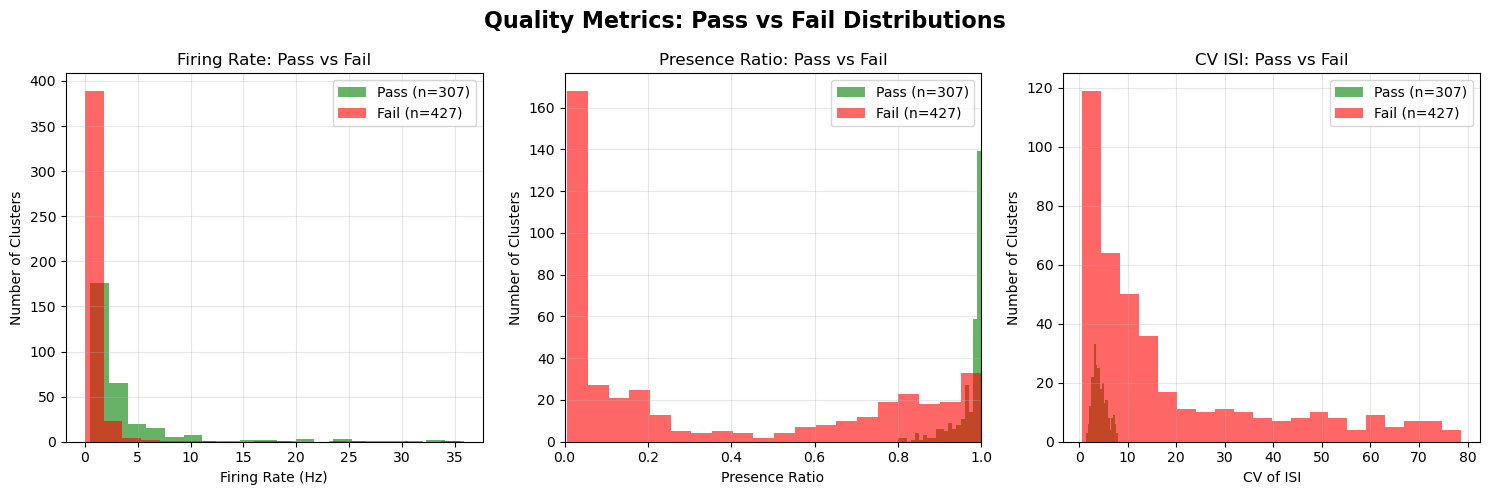

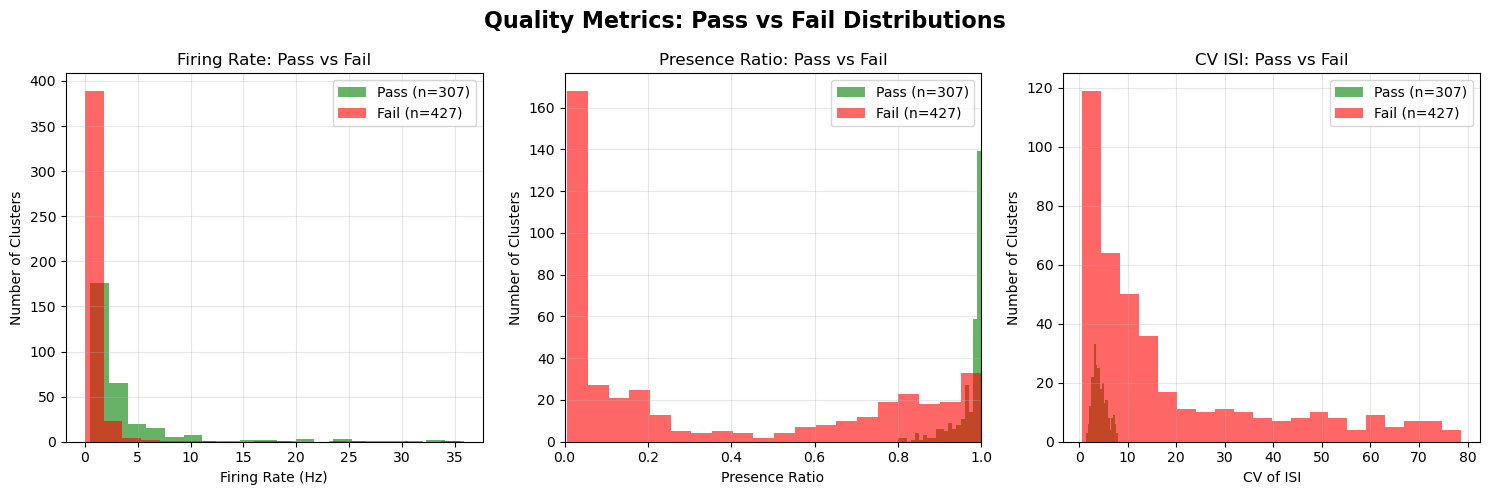

In [10]:
# Calculate firing pattern metrics and filter cells based on those metrics
import ephys.plot_ephys_qa_stats as pqa

metrics = ks_data.calculate_firing_pattern_metrics()
cells_filtered = ks_data.filter_cells_by_firing_patterns()
ks_data.print_firing_pattern_summary()
pqa.plot_pass_fail_histograms(metrics, cells_filtered)

In [ ]:
# Load and plot video tracking data
from video.tracking_import import VideoTrackingData
import video.plot_trajectory as pt

data_storage2 = DataStorageManager("rat631", "20251210", auto_load=True)
tracking_data = VideoTrackingData(data_storage2)
objects = tracking_data.get_object_names()
trajectory = tracking_data.get_object_trajectory(objects[0])
tracking_summary = tracking_data.export_summary()

Loading data paths for rat631/20251210
Data Availability Summary:
  - Ephys (Kilosort): ✓
  - DIO channels: [1, 2, 3, 4]
  - Video files: 49
  - Tracking files: 2
  - Behavioral event files: 0
  - Pulse log: ✓
Using tracking file from DataStorageManager: \\nearline\karpova\TervoLab\analysis\Tracking\manual_tracking\cohort7\RatCity_20251210_1359_40Hz\RatCity_20251210_1359_40Hz_mask_metrics.csv
Loading tracking data from: \\nearline\karpova\TervoLab\analysis\Tracking\manual_tracking\cohort7\RatCity_20251210_1359_40Hz\RatCity_20251210_1359_40Hz_mask_metrics.csv
Using tracking file from DataStorageManager: \\nearline\karpova\TervoLab\analysis\Tracking\manual_tracking\cohort7\RatCity_20251210_1359_40Hz\RatCity_20251210_1359_40Hz_mask_metrics.csv
Successfully loaded tracking data: 862048 rows, 13 columns
Parsing tracking data by objects...
Parsed object '613': 71842 rows, 11 columns
Parsed object '615': 71843 rows, 11 columns
Parsed object '616': 71804 rows, 11 columns
Parsed object '617': 7

Plotted path for rat631: 71844 points, 44519.6 pixels total distance
Plotted paths for 12 animals
Created occupancy-based Voronoi territorial diagram with 2732 seed points from 12 animals
Analyzing proximity interactions with threshold 100 pixels...
Found 35 significant interactions between animals

Proximity Network Analysis Results:
  Animals analyzed: 12
  Significant interactions: 35
  Network density: 0.530


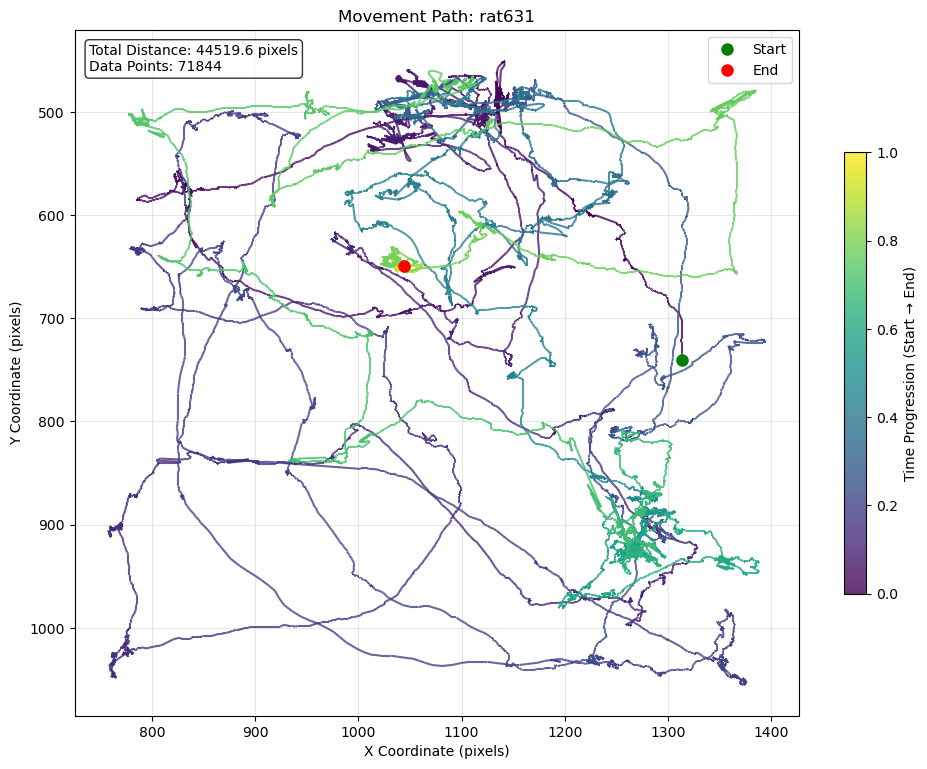

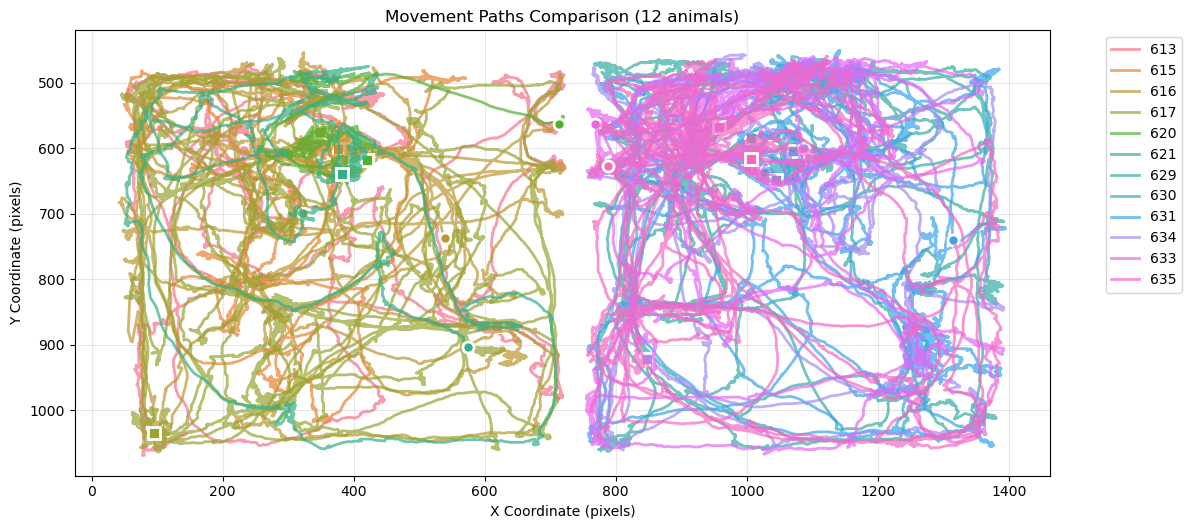

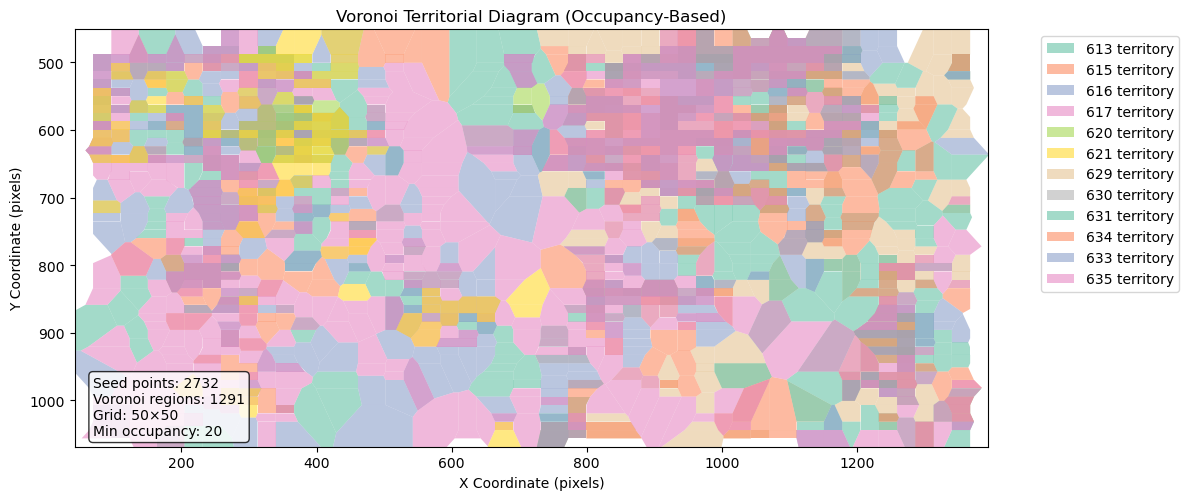

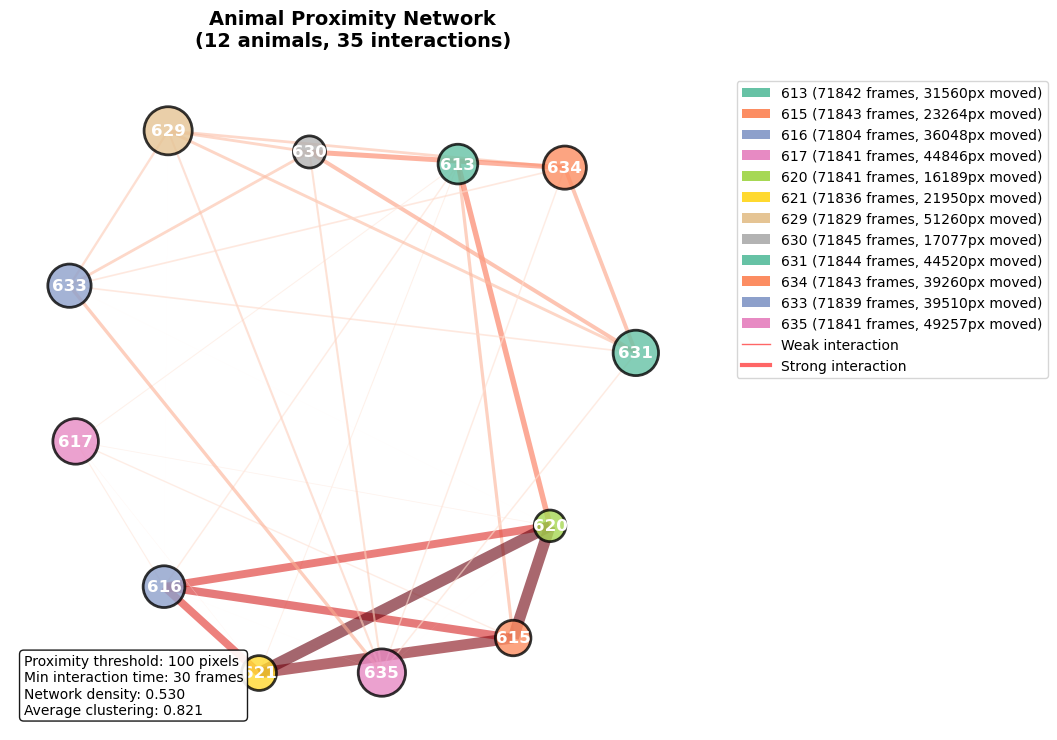

In [14]:
# Plotting examples for animal paths, territorial occupancy, Voronoi territories, and proximity networks
fig1 = pt.plot_animal_path(tracking_data.parsed_data['631'], 'rat631')
fig2 = pt.plot_multiple_paths(tracking_data.parsed_data)
# fig3 = pt.plot_territorial_occupancy(tracking_data.parsed_data)
fig4 = pt.plot_voronoi_territories(tracking_data.parsed_data)
fig5 = pt.plot_proximity_network(tracking_data.parsed_data)

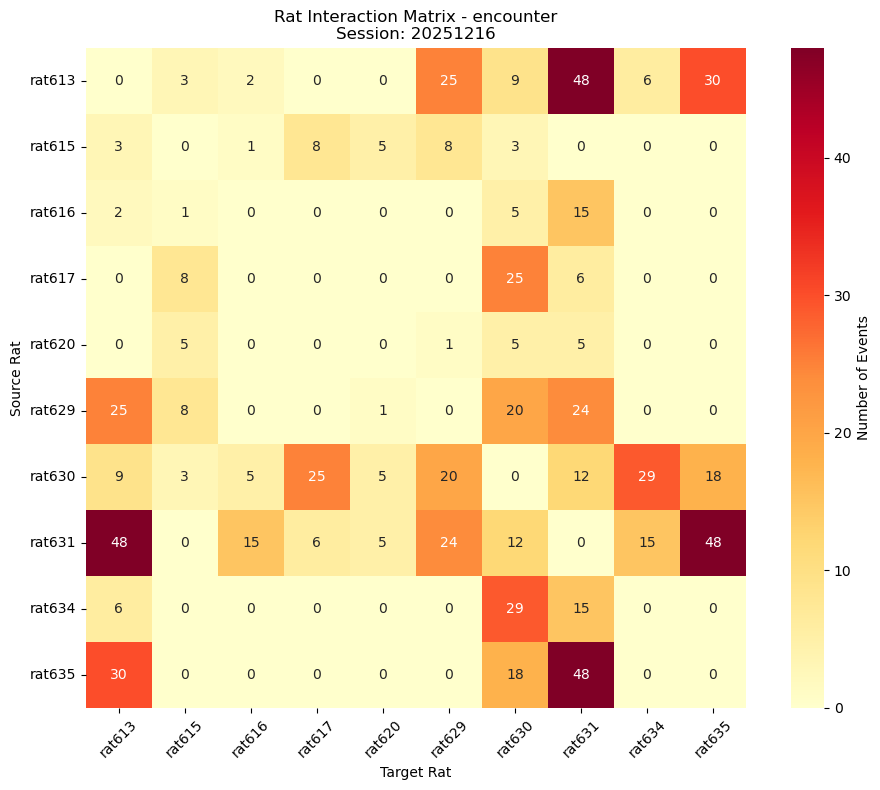

Found 233 events for rat rat631 (role: any)


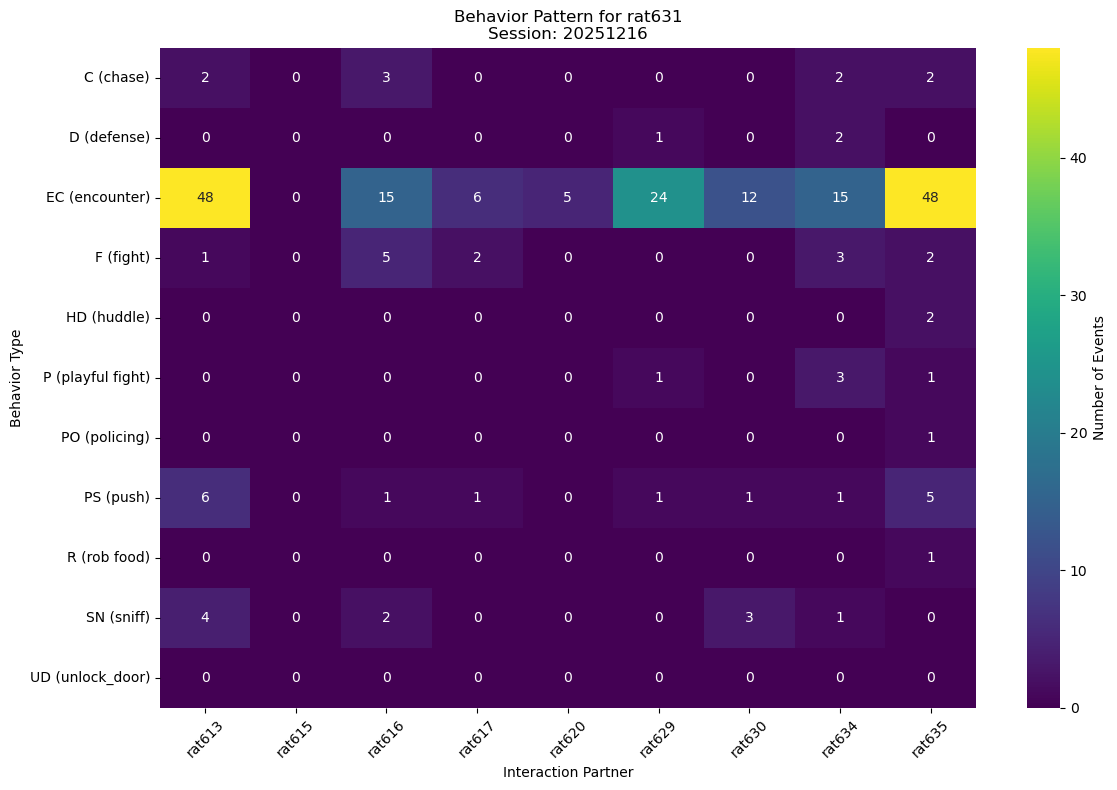

In [ ]:
# Plotting examples for interaction heatmaps and behavior heatmaps
behavior_data.plot_rat_interaction_heatmap(event_type='EC')
behavior_data.plot_rat_behavior_heatmap('631')

Successfully loaded 1 file(s) with 641 total events
✓ Available behavior types: {'EC': 376, 'F': 71, 'PS': 71, 'C': 46, 'SN': 31, 'D': 16, 'P': 15, 'PO': 5, 'R': 5, 'HD': 4, 'UD': 1}
✓ Found 96 EC events with opponent labels
✓ Unique opponents: ['rat613' 'rat635']
✓ Found 96 encounter events with opponent labels
✓ Unique opponents: ['rat613' 'rat635']
✓ Found 96 EC events with opponent labels
✓ Unique opponents: ['rat613' 'rat635']
Found 96 behavioral events
Using 210 quality-filtered cells
Processing cell 1/210 (cluster 126)
Processing cell 51/210 (cluster 551)
Processing cell 101/210 (cluster 846)
Processing cell 151/210 (cluster 1043)
Processing cell 201/210 (cluster 1210)
Successfully decoded 210/210 cells
✓ Found 96 EC events with opponent labels
✓ Unique opponents: ['rat613' 'rat635']


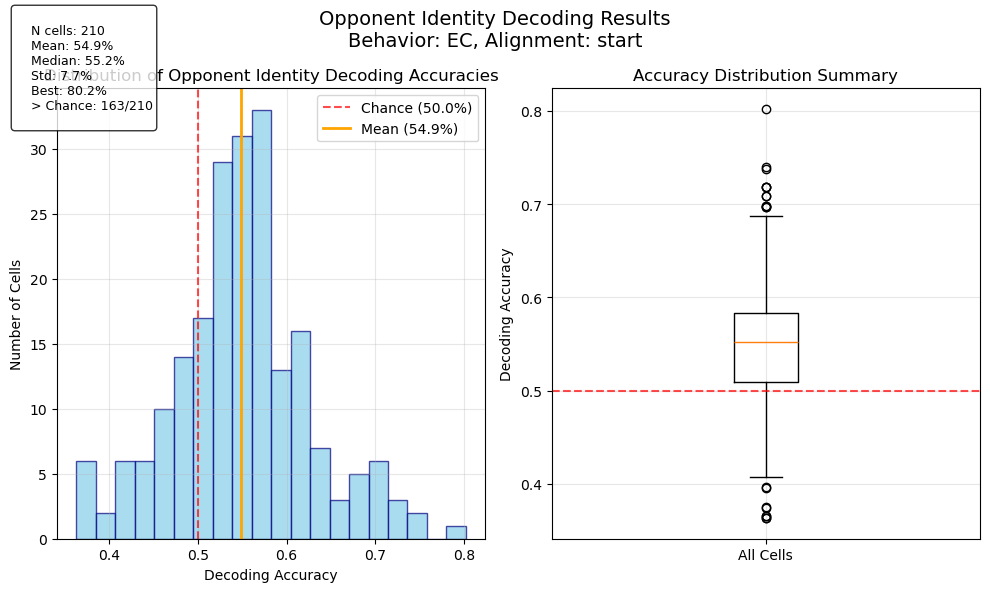

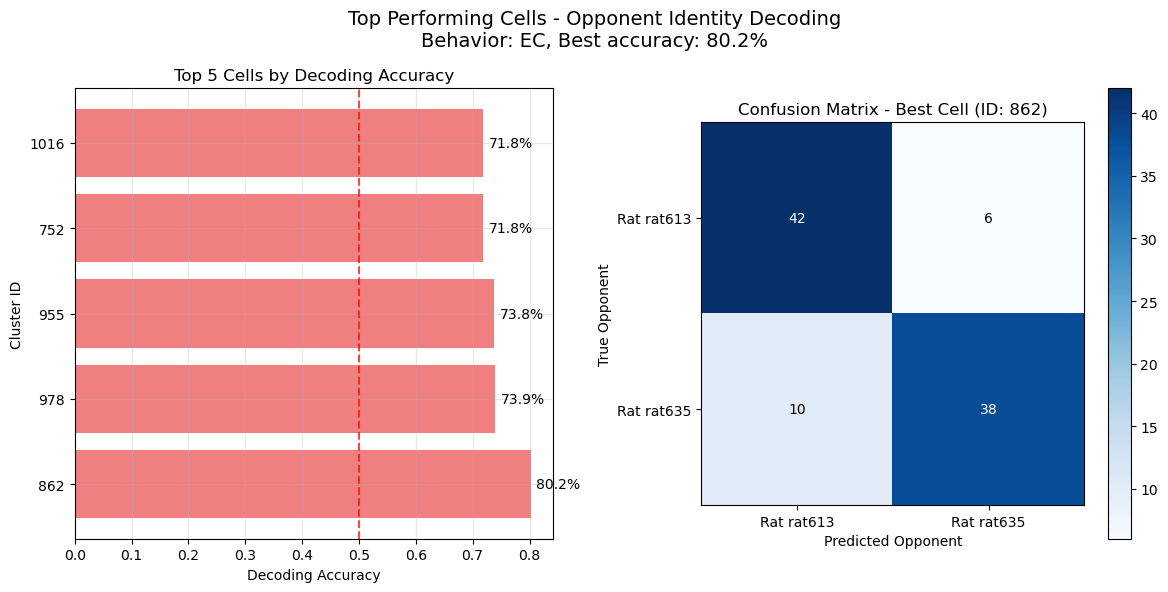

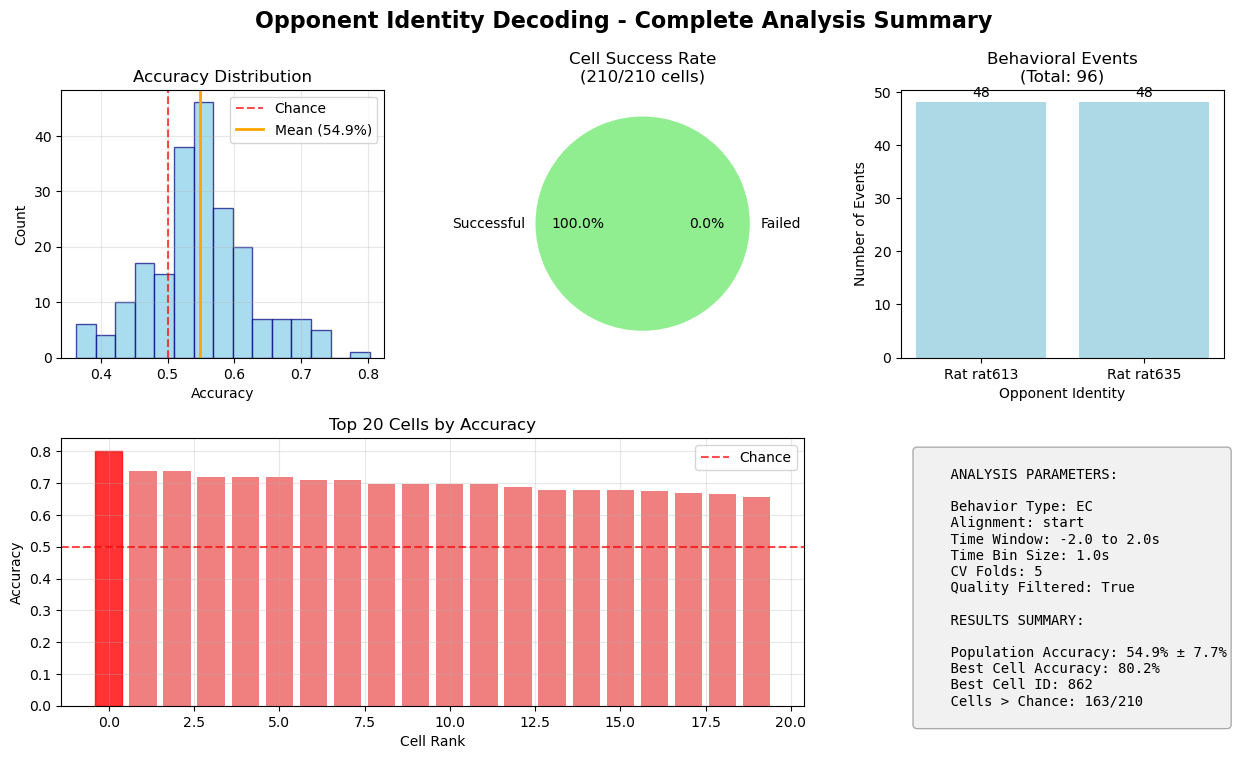

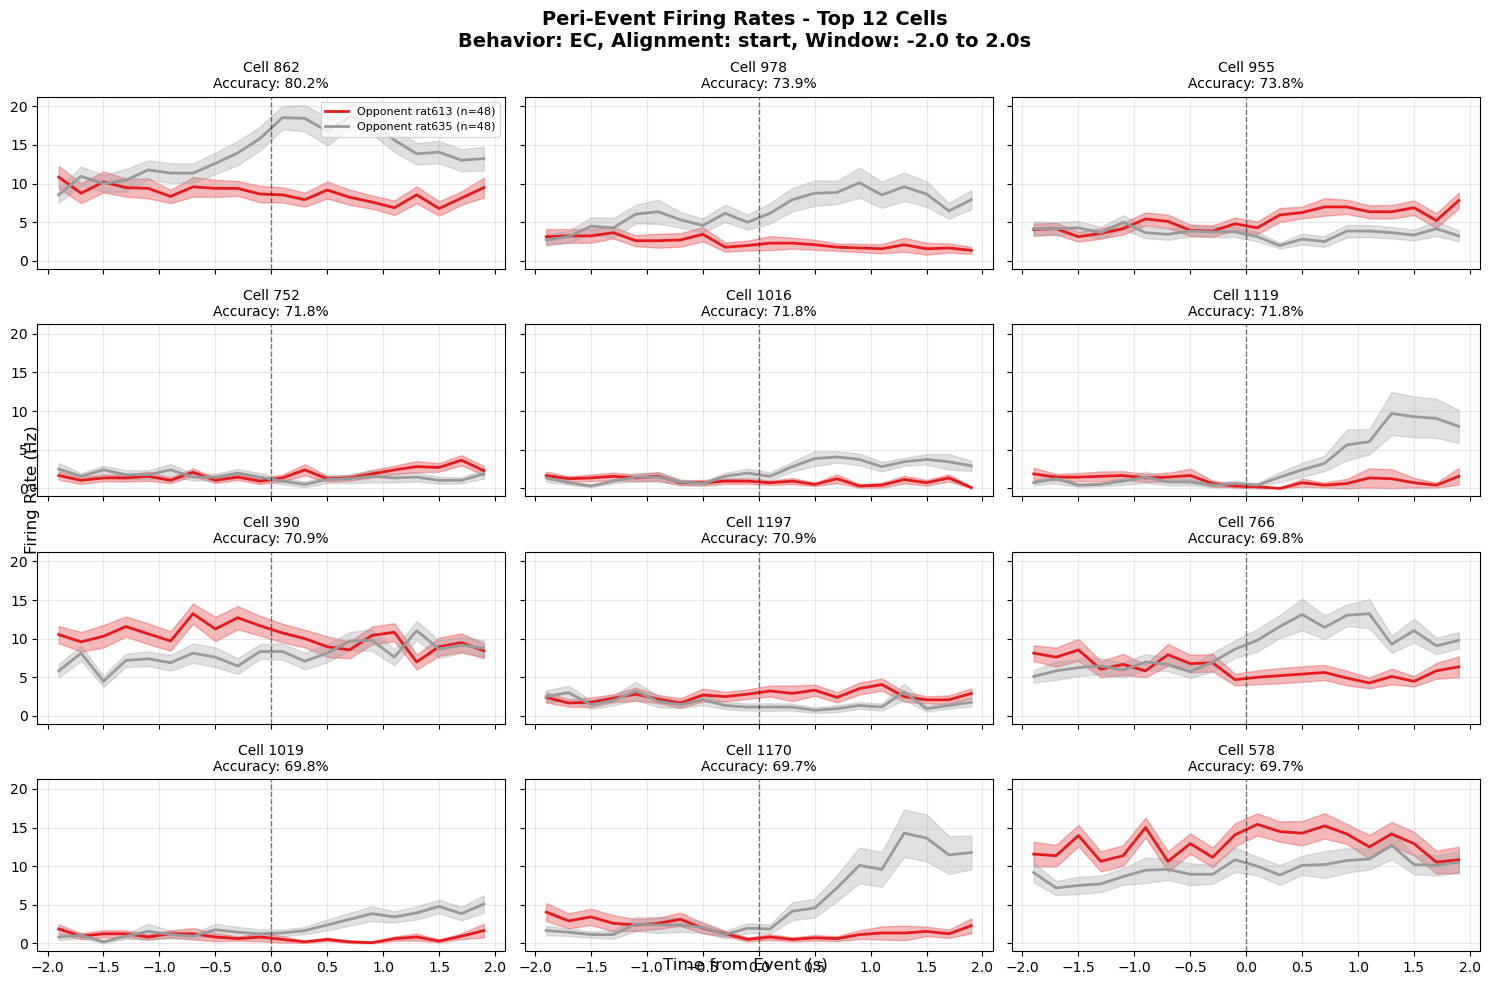

In [17]:
# Decode opponent identity for encounter events
import ephys.decode_opponent_identity as doi
import numpy as np
animal_id = "rat631"

# Create data manager and load behavioral events
behavior_data = BehavioralEventsData(data_storage)
behavior_data.synchronize_with_ephys(sync, create_new_columns=True)


# Test extracting opponent labels for fights with animal of interest
event_starts, event_ends, opponent_labels = behavior_data.extract_opponent_labels( 
    animal_of_interest=animal_id,
    behavior_type='EC',
    min_events_per_class=30
)
print(f"✓ Found {len(event_starts)} encounter events with opponent labels")
print(f"✓ Unique opponents: {np.unique(opponent_labels)}")

# Run decoding with a small subset for testing
test_results = doi.decode_opponent_identity_population(
    ks_data=ks_data,
    behavior_data=behavior_data,
    animal_of_interest=animal_id,
    behavior_type='EC',  # Encounter events
    use_quality_cells=True,
    alignment='start',
    time_window=(-2.0, 2.0),  # Smaller window for faster testing
    time_bin_size=1.0, # Larger bins for faster testing
    cv_folds=5,  # Fewer folds for faster testing
    min_events_per_class=30  # Lower threshold for testing
)
         
# Accuracy distribution plot
fig1 = doi.plot_decoding_accuracy_distribution(test_results, figsize=(10, 6))

# Best cells plot
fig2 = doi.plot_best_cells_decoding(test_results, n_top_cells=5, figsize=(12, 6))
    
# Summary plot
fig3 = doi.plot_decoding_summary(test_results, figsize=(15, 8))

# Plot firing rates of top cells around events
fig4 = doi.plot_top_cells_firing_rates(
            ks_data=ks_data,
            behavior_data=behavior_data, 
            test_results=test_results,
            time_window=(-2.0, 2.0),  # Same as analysis window
            time_bin_size=0.2,       # Finer resolution for PETH
            n_top_cells=12,            # Show top 6 cells
            figsize=(15, 10)
        )

In [12]:
# Test the new save functionality
print("💾 Testing KilosortData save/load functionality...")

if 'ks_data' in locals() and ks_data is not None:
    try:
        # 1. List any existing saved files
        print("\n1. Checking for existing saved files...")
        existing_files = ks_data.list_saved_files()
        
        # 2. Save full dataset
        print("\n2. Saving full KilosortData object...")
        full_save_path = ks_data.save_to_file(
            # filename="test_full_dataset.pkl",
            exclude_large_arrays=False,
            compression=True
        )
        
        # 3. Save processed data only (smaller file)
        print("\n3. Saving processed data only (lightweight)...")
        processed_save_path = ks_data.save_to_file(
            # filename="test_processed_only.pkl", 
            exclude_large_arrays=True,
            compression=True
        )
        
        # 4. List files again to see the new saves
        print("\n4. Updated file listing:")
        current_files = ks_data.list_saved_files()
        
        # 5. Test loading the processed version
        print("\n5. Testing load from processed file...")
        try:
            loaded_ks = kdi.KilosortData.load_from_file(processed_save_path)
            
            print(f"✅ Successfully loaded processed data!")
            print(f"   🐭 Animal: {loaded_ks.animal_id}")
            print(f"   📅 Session: {loaded_ks.session_id}")
            print(f"   🧠 Clusters: {len(loaded_ks.ks_ids)}")
            print(f"   🔢 Spike times by cell available: {hasattr(loaded_ks, 'spike_times_by_cell')}")
            
            # Check if quality metrics are preserved
            if hasattr(loaded_ks, 'ks_ids'):
                test_metrics = loaded_ks.calculate_firing_pattern_metrics()
                print(f"   📊 Quality metrics calculable: {len(test_metrics) > 0}")
            
        except Exception as e:
            print(f"❌ Error loading processed file: {e}")
        
        # 6. Test loading with fresh data input (for processed-only saves)
        print("\n6. Testing load with fresh data input...")
        try:
            if 'data_storage' in locals():
                reloaded_ks = kdi.KilosortData.load_from_file(
                    processed_save_path, 
                    data_input=data_storage
                )
                print(f"✅ Successfully reloaded with fresh data input!")
                print(f"   🔄 Has raw spike times: {hasattr(reloaded_ks, 'spike_times')}")
                print(f"   🔄 Spike times length: {len(reloaded_ks.spike_times) if hasattr(reloaded_ks, 'spike_times') else 'N/A'}")
                
        except Exception as e:
            print(f"❌ Error reloading with data input: {e}")
            
        print("\n" + "="*60)
        print("SAVE/LOAD FUNCTIONALITY SUMMARY:")
        print("✅ Full save: Complete dataset with all raw data")  
        print("✅ Processed save: Lightweight file with analysis results only")
        print("✅ Load from file: Restore saved KilosortData objects")
        print("✅ File listing: Browse available saves with metadata")
        print("✅ Hybrid loading: Combine processed saves with fresh raw data")
        print("="*60)
        
    except Exception as e:
        print(f"❌ Error testing save/load functionality: {e}")
        import traceback
        traceback.print_exc()
else:
    print("❌ No KilosortData object available for testing")
    print("   Run the earlier cells to create ks_data first")

print("\n🎯 Use cases for the save functionality:")
print("   • 💾 Cache processed results to avoid re-computation")
print("   • 📤 Share datasets with colleagues")  
print("   • 🔄 Create analysis checkpoints")
print("   • 💡 Lightweight processed-only saves for large datasets")
print("   • 🚀 Quick loading of pre-computed metrics and filtered cells")

💾 Testing KilosortData save/load functionality...

1. Checking for existing saved files...
📂 Found 2 saved KilosortData files:
   💾 kilosort_full_rat631_20251220_094752_20260320_142107.pkl
      Size: 593.36 MB, Modified: 2026-03-20 14:21:20
   🔧 kilosort_processed_rat631_20251220_094752_20260320_142120.pkl
      Size: 96.87 MB, Modified: 2026-03-20 14:21:23

2. Saving full KilosortData object...
✅ KilosortData saved successfully!
   📁 File: \\nearline\karpova\TervoLab\data\Electrophysiology\Raw\rat_city\cohort7\20251220_094752.rec\rat631\20251220_094752_merged.kilosort\kilosort4\kilosort_full_rat631_20251220_094752_20260320_142512.pkl
   📊 Size: 593.36 MB
   🔧 Object type: Full dataset

3. Saving processed data only (lightweight)...
✅ KilosortData saved successfully!
   📁 File: \\nearline\karpova\TervoLab\data\Electrophysiology\Raw\rat_city\cohort7\20251220_094752.rec\rat631\20251220_094752_merged.kilosort\kilosort4\kilosort_processed_rat631_20251220_094752_20260320_142525.pkl
   📊 Si

✓ Found 173 EC events with opponent labels
✓ Unique opponents: ['rat613' 'rat616' 'rat617' 'rat620' 'rat629' 'rat630' 'rat634' 'rat635']


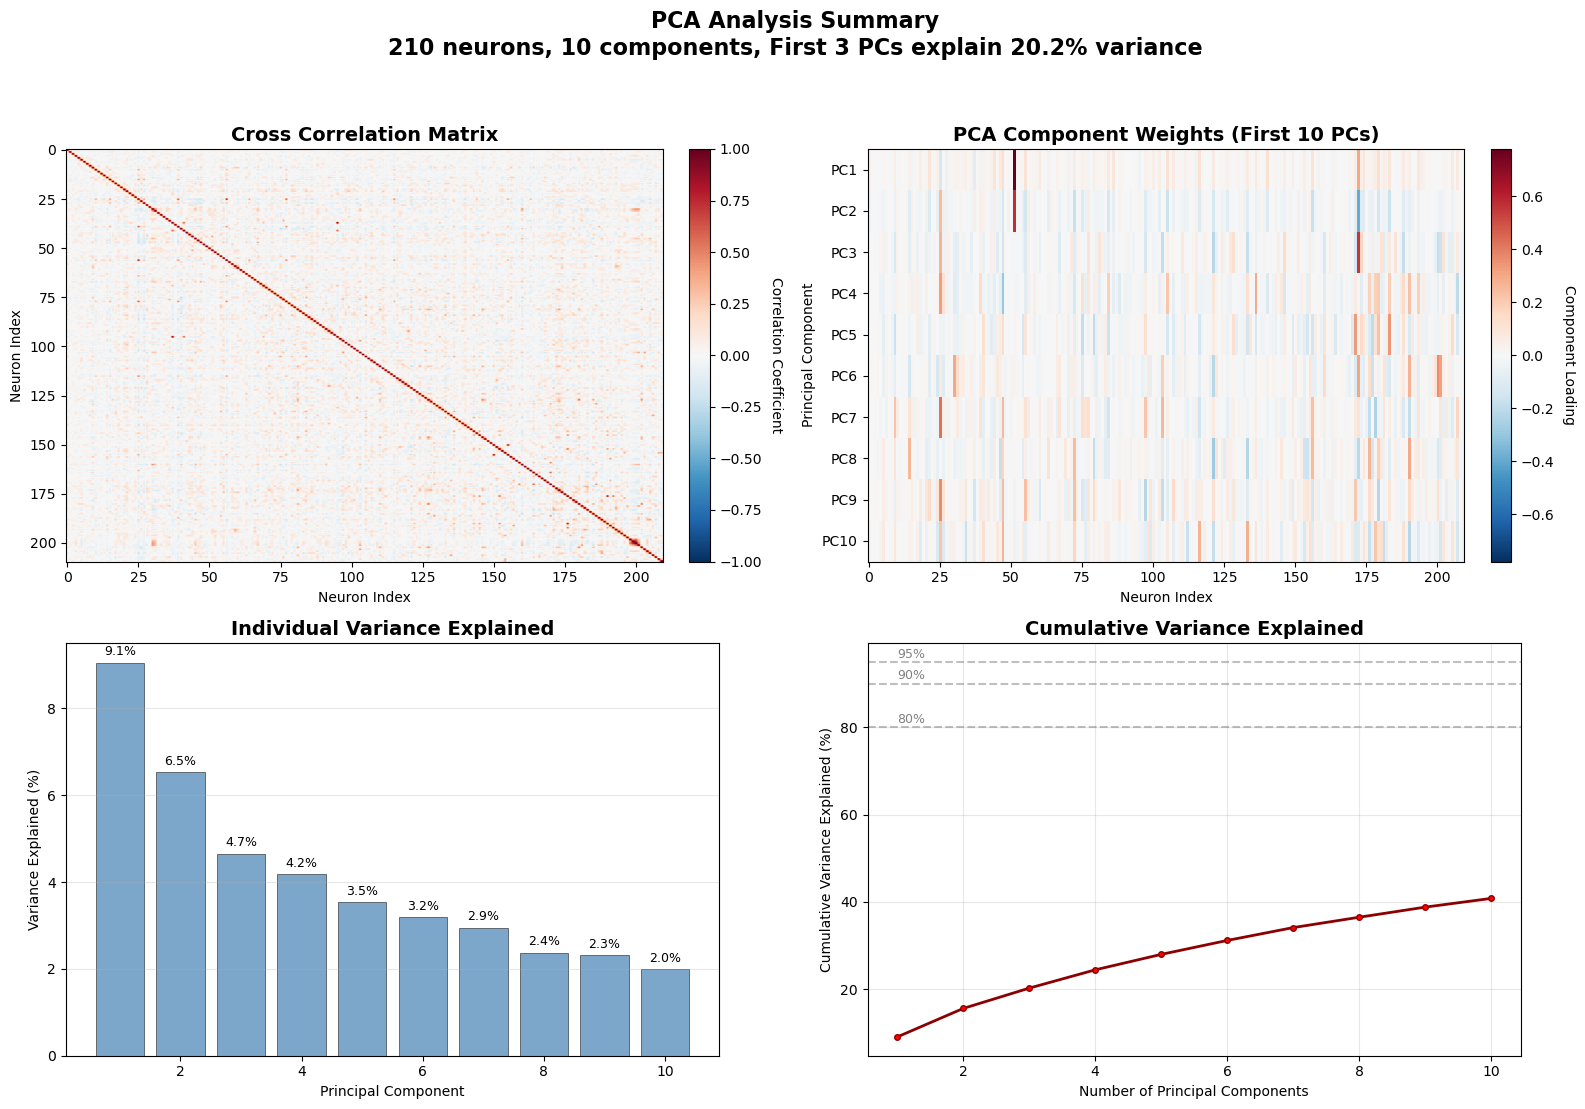

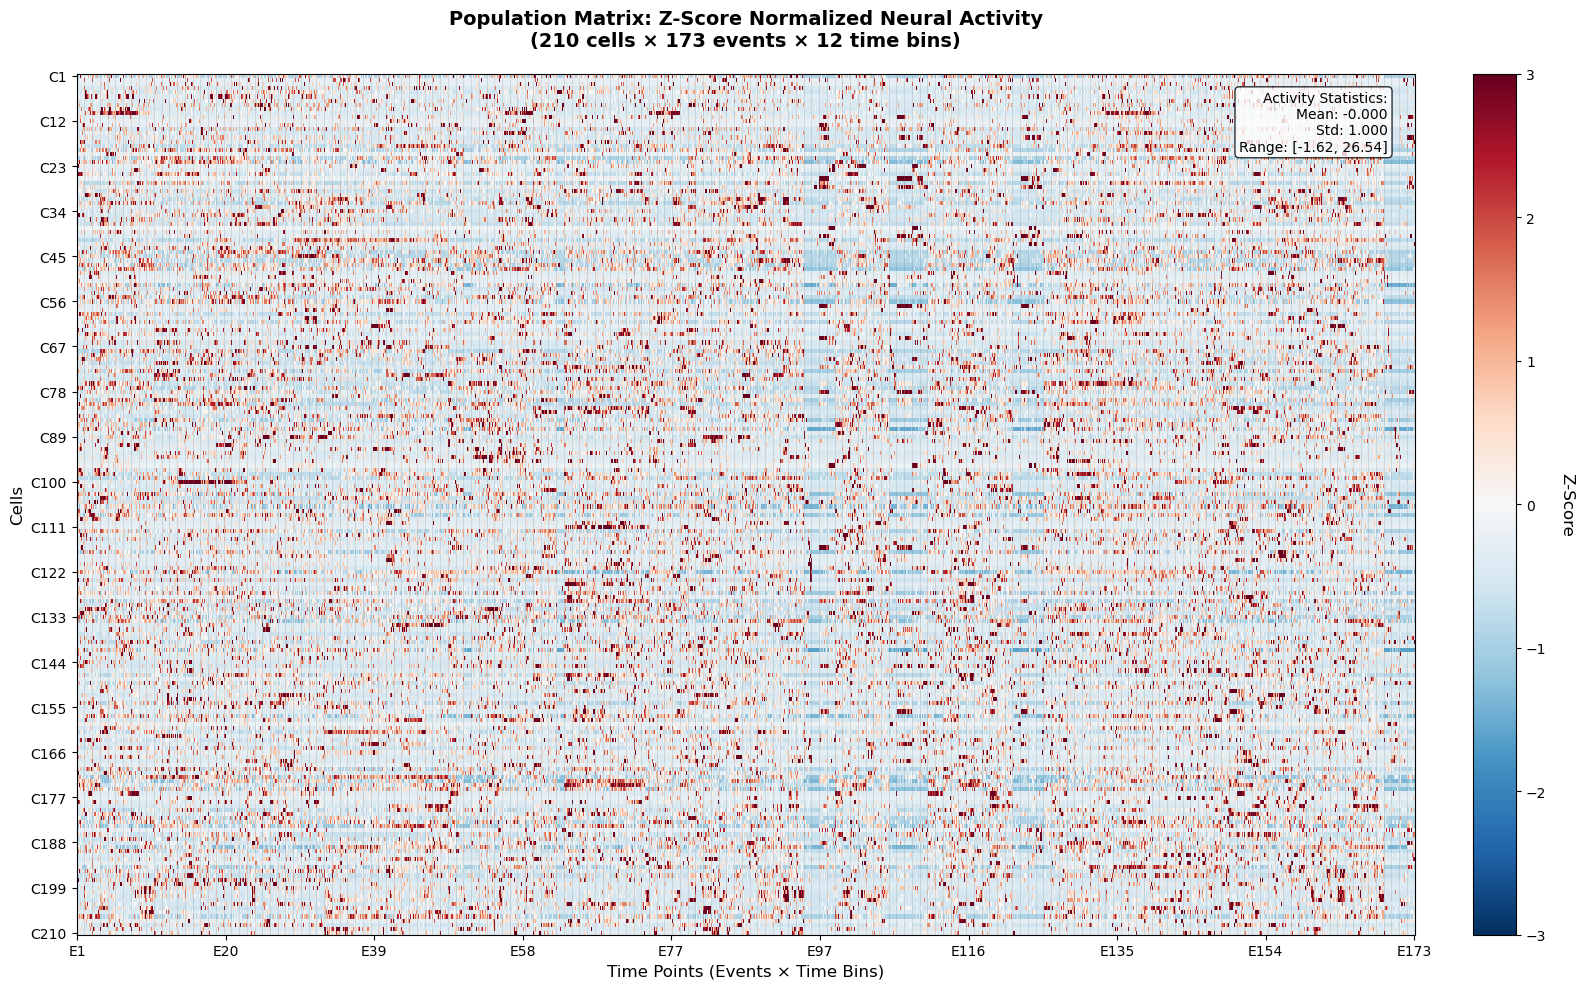

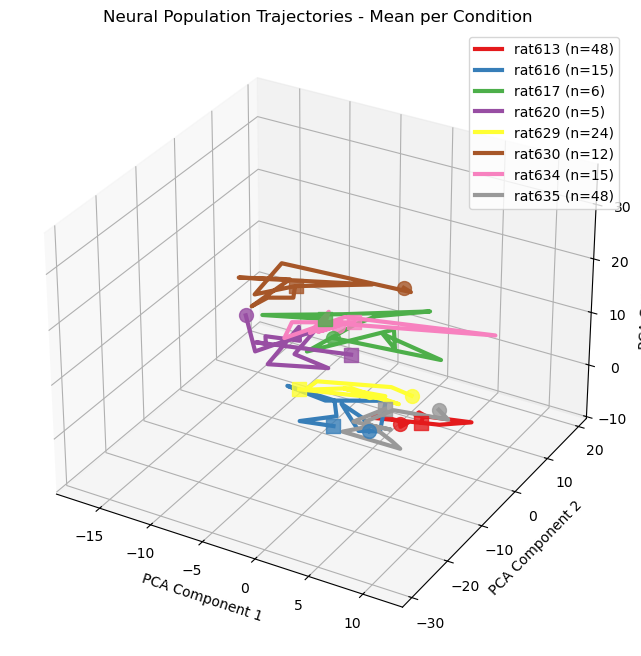

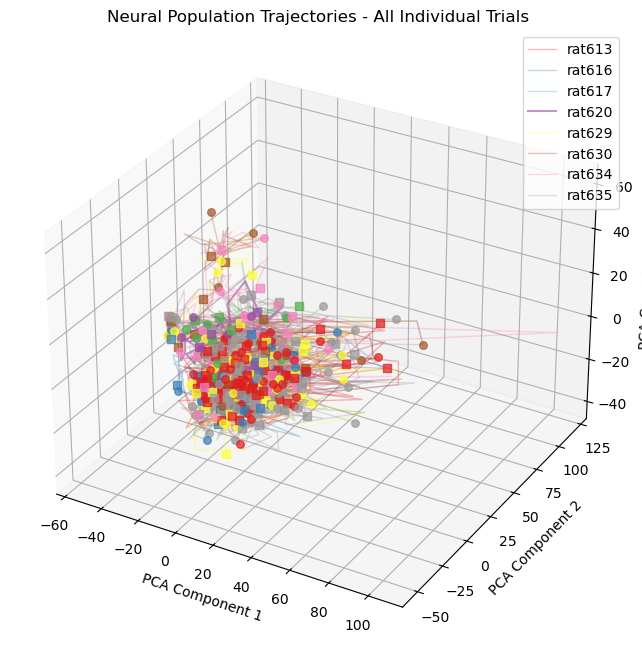

In [18]:
# Test population geometry analysis and plotting
import importlib
import ephys.population_geometry as pg
importlib.reload(pg)  # Reload the population geometry module to ensure we have the latest version
analyzer = pg.PopulationGeometryAnalyzer(ks_data, behavior_data)
event_starts, event_ends, opponent_labels = behavior_data.extract_opponent_labels(
    animal_of_interest="rat631",
    behavior_type='EC',
    min_events_per_class=5
)

if len(event_starts) > 0:
    # Test baseline normalization
    pop_matrix = analyzer.construct_population_matrix(
        event_starts=event_starts,
        event_ends=event_ends,
        event_labels=opponent_labels,
        time_window=(-2.0, 4.0),
        time_bin_size=0.5,
        alignment='start',
        normalize_method='none'  # Different normalization
    )
reduced_data = analyzer.apply_dimensionality_reduction(pop_matrix, method='PCA', n_components=10)
fig_pca_summary = analyzer.plot_pca_summary(
        reduced_data=reduced_data, 
        pop_data=pop_matrix['population_data'],  # Pass original population data
        figsize=(16, 12)
    )

fig_normalized = analyzer.plot_normalized_population_matrix(
    pop_data=pop_matrix['population_data'],
    figsize=(16, 10)
)
fig_mean = analyzer.plot_population_dynamics(reduced_data, show_individual=False)
fig_individual = analyzer.plot_population_dynamics(reduced_data, show_individual=True)